# 4. projekt (minta)


# Feladat

Oldja meg (közelítő) `hatványsor` módszerrel a következő kezdeti érték feladatot:
\begin{gather*}
    y'' - 2y' - y = 1+t\\
    y(0)=2\\
    y'(0)=-\frac{2}{10}\\
\end{gather*}

---

\begin{gather*}
y(2.9)=?
\end{gather*}

A megoldást számolja ki $5.,10.,20.,30.$ rendű tagig és hasonlítsa össze ```ode45``` által számolttal!


# Megoldás

* Írjuk fel a jobboldalt hatványsor alakban.
  (Itt most ez könnyű: $\sum_{k\ge0}b_k t^k,\ \ b_k=[1,1,0,0,...]$)
* Keressük a megoldást $f(t)=\sum_{k\ge0} a_k t^k$  (hatványsor) alakban.
* A kezdeti feltételek meghatározzák $a_0,a_1$-et
* Helyettesítsük be $f$-et az egyenletbe (baloldal)
* Vessük össze a baloldal együtthatóit a jobboldal együtthatóival.
  * megfelelő átindexelést alkalmazva:
  * $f'(t)=\sum_{k=1} ka_{k}t^{k-1} = \sum_{k=0} (k+1)a_{k+1}t^k$
  * $f''(t)=\sum_{k=1} (k+1)ka_{k+1}t^{k-1} = \sum_{k=0} (k+2)(k+1)a_{k+2}t^k$
* Az $a_k$ sorozatra kapott összefüggések segítségével $f$-et akárhány tagig ki tudjuk számolni
* (Zárt alakot is kereshetünk az $a_k$ sorozatra - ez *általában* nehéz és nem is célunk.)


\begin{gather*}
a_0=y(0)=2 \\
a_1=y'(0)=-\frac{2}{10} \\
\end{gather*}

\begin{gather*}
f''(t)=\sum_{k\ge2} a_{k}k(k-1)t^{k-2}=
\sum_{k\ge0} a_{k+2}(k+2)(k+1)t^{k}\\
-2f'(t)=\sum_{k\ge1} -2a_{k}k t^{k-1} =
\sum_{k\ge0} -2a_{k+1}(k+1) t^{k}\\
-f(t) = \sum_{k\ge0} -a_{k}t^k
\end{gather*}

A rekurzió általános alakja $k\ge 0$ esetben:
\begin{gather*}
a_{k+2}(k+2)(k+1)-2a_{k+1}(k+1)-a_k = b_k \\
a_{k+2}=\frac{b_k+2a_{k+1}(k+1)+a_k}{(k+2)(k+1)}
\end{gather*}



# Python

Létrehozunk egy polinomot - a megoldás egy részletösszegét - a fenti rekurzionak megfelelő együtthatókkal, stb, stb...

In [9]:
import numpy as np
# a függvény csak az adott feladatot egy N-fokú hatványsoros közelítését (p-polinom) adja vissza
def hatvsor(N,y0,dy0):
  a=np.zeros(N+1)
  a[0]=y0
  a[1]=dy0
  
  b=np.zeros(N+1)
  b[0]=1
  b[1]=1
  
  # a rekurzióban szereplő a(k+2)-t számoljuk
  for k in range(0,N-1):
    a[k+2]=(b[k]+2*a[k+1]*(k+1)+a[k])/((k+2)*(k+1))
  
  return a[::-1] # az algo novekvő fokszámmal dolgozik


In [20]:
import scipy as scp

# számolások


# kezdeti feltételek
y0=2; dy0=-0.2
t0=0; tv=2.9

t = np.linspace(t0, tv); # mindegyiknel ezt hasznalja

p5 = hatvsor(5,y0,dy0);
y5 = np.polyval(p5, t);

p10 = hatvsor(10,y0,dy0);
y10 = np.polyval(p10, t);

p20 = hatvsor(20,y0,dy0);
y20 = np.polyval(p20, t);


# hasonlóan mint a projekt 2-ben:
f=lambda t,y,dy: t + 1 + y + 2*dy
F=lambda t,v: np.array([v[1], f(t,v[0],v[1])]) 

Y0=np.array([y0,dy0])
tspan=np.array([t0,tv])
rk45=scp.integrate.solve_ivp(F, tspan, Y0, method = "RK45")
t45 = rk45.t     # rk45.t: (n,)
y45 = rk45.y[0]  # rk45.y: (1,n)

Text(0.5, 1.0, 'fokszám=20\n y(2.9)=469.612118719\n delta=0.058856925')

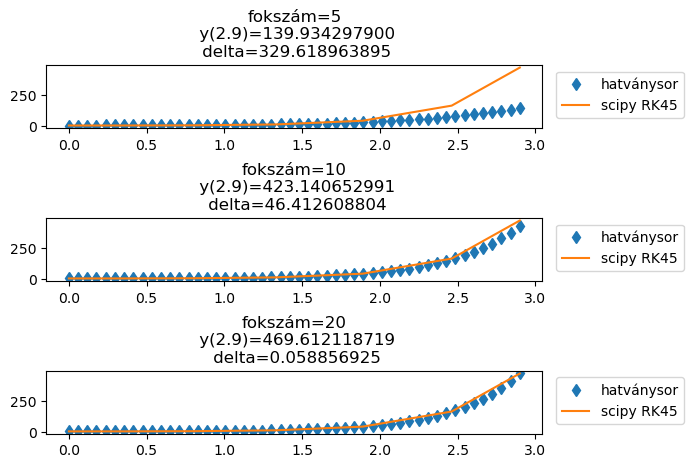

In [22]:
# külön ábrák hogy lássuk a becslés "javulását"
import matplotlib.pyplot as plt

deg=5
ax = plt.subplot(5,1,1)
ax.plot(t, y5,'d')
ax.plot(t45, y45)
plt.legend(
  ["hatványsor", "scipy RK45"],
  bbox_to_anchor=(1.3, 1.0)
)
plt.title(f"fokszám={deg}\n y({tv})={y5[-1]:.9f}\n delta={np.abs(y5[-1]-y45[-1]):.9f}")

deg=10
ax = plt.subplot(5,1,3)
ax.plot(t, y10,'d')
ax.plot(t45, y45)
plt.legend(
  ["hatványsor", "scipy RK45"],
  bbox_to_anchor=(1.3, 1.0)
)
plt.title(f"fokszám={deg}\n y({tv})={y10[-1]:.9f}\n delta={np.abs(y10[-1]-y45[-1]):.9f}")

deg=20
ax = plt.subplot(5,1,5)
ax.plot(t, y20,'d')
ax.plot(t45, y45)
plt.legend(
  ["hatványsor", "scipy RK45"],
  bbox_to_anchor=(1.3, 1.0)
)
plt.title(f"fokszám={deg}\n y({tv})={y20[-1]:.9f}\n delta={np.abs(y20[-1]-y45[-1]):.9f}")